In [ ]:
import os
import numpy as np
import pandas as pd
from collections import Counter

from evaluation.count_cycles import GraphTools


In [1]:

base_dir = r"D:\Vtech\vibeRank\responses"

In [6]:
file_configs = [
    # VISPDAT
    {"dataset": "VISPDAT", "model": "QWEN", "file": "QWEN_vispdat_20260428_133227.csv"},
    {"dataset": "VISPDAT", "model": "LLAMA", "file": "ParseLLAMA_vispdat_20260428_184821.csv"},
    {"dataset": "VISPDAT", "model": "DeepSeek8B", "file": "Parseddeepseek8B_vispdat_20260428_203611.csv"},

    # VIFSPDAT
    {"dataset": "VIFSPDAT", "model": "QWEN", "file": "ParsedQWEN_vispdat.csv"},
    {"dataset": "VIFSPDAT", "model": "LLAMA", "file": "ParseLLAMA_vifspdat.csv"},
    {"dataset": "VIFSPDAT", "model": "DeepSeek8B", "file": "Parseddeepseek8B_vifspdat.csv"},

    # TAYVISPDAT
    {"dataset": "TAYVISPDAT", "model": "QWEN", "file": "ParsedQWEN_TAY.csv"},
    {"dataset": "TAYVISPDAT", "model": "LLAMA", "file": "llama_TAY_parsed.csv"},
    {"dataset": "TAYVISPDAT", "model": "DeepSeek8B", "file": "DS_TAY_parsed.csv"},
]


In [8]:
def normalize_winner(x):
    if pd.isna(x):
        return "indeterminate"

    x_raw = x
    x = str(x).strip().lower()

    if x in ["household1", "household 1", "1", "left"]:
        return "household1"

    if x in ["household2", "household 2", "2", "right"]:
        return "household2"

    if x in [
        "indeterminate",
        "inderminate",
        "inderterminate",
        "undetermined",
        "unknown",
        "tie",
        "neither",
        "none",
        "nan",
    ]:
        return "indeterminate"

    return f"unknown::{x_raw}"


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_win_matrix(
    win_matrix,
    house_ids=None,
    title="Win matrix",
    annotate=False,
    figsize=(8, 7),
    save_path=None,
    show=True,
    hide_labels_threshold=40,
):
    """
    Visualize win_matrix.

    win_matrix[i, j] = number of times house_ids[i] beat house_ids[j]

    Rows = winner household
    Columns = loser household
    """

    mat = np.array(win_matrix, dtype=float)

    # Optional: hide diagonal because a household should not be compared with itself
    mat_to_plot = mat.copy()
    np.fill_diagonal(mat_to_plot, np.nan)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(mat_to_plot, interpolation="nearest")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("# wins: row household beat column household")

    n = win_matrix.shape[0]

    ax.set_title(title)
    ax.set_xlabel("Column household: loser")
    ax.set_ylabel("Row household: winner")

    if house_ids is not None and n <= hide_labels_threshold:
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))

        ax.set_xticklabels(house_ids, rotation=90, fontsize=7)
        ax.set_yticklabels(house_ids, fontsize=7)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    if annotate and n <= 25:
        for i in range(n):
            for j in range(n):
                if i != j and win_matrix[i, j] > 0:
                    ax.text(
                        j,
                        i,
                        str(int(win_matrix[i, j])),
                        ha="center",
                        va="center",
                        fontsize=7,
                    )

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax

In [12]:
import os
import json
import numpy as np


def safe_name(x):
    return (
        str(x)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
    )


output_dir = "raw_win_matrices"
os.makedirs(output_dir, exist_ok=True)

In [10]:
import numpy as np
import pandas as pd

def load_one_file(dataset, model, file_name):
    file_path = os.path.join(base_dir, dataset, "rc_responses", file_name)

    df = pd.read_csv(file_path)
    df = df[["left_item", "right_item", "more_vulnerable_household"]].copy()

    df["dataset"] = dataset
    df["model"] = model
    df["file"] = file_name
    df["winner_clean"] = df["more_vulnerable_household"].apply(normalize_winner)
    df["row_order"] = np.arange(len(df))

    return df


def build_win_count_matrix_for_file(dataset, model, file_name):
    df = load_one_file(dataset, model, file_name)

    house_ids = sorted(set(df["left_item"]).union(set(df["right_item"])))
    house_to_idx = {house_id: idx for idx, house_id in enumerate(house_ids)}
    idx_to_house = {idx: house_id for house_id, idx in house_to_idx.items()}

    num_house = len(house_ids)

    # win_matrix[i, j] = number of times house_ids[i] beat house_ids[j]
    win_matrix = np.zeros((num_house, num_house), dtype=int)

    valid = df[df["winner_clean"].isin(["household1", "household2"])].copy()

    for row in valid.itertuples(index=False):
        left = row.left_item
        right = row.right_item
        winner = row.winner_clean

        left_idx = house_to_idx[left]
        right_idx = house_to_idx[right]

        if winner == "household1":
            # left household beat right household
            win_matrix[left_idx, right_idx] += 1

        elif winner == "household2":
            # right household beat left household
            win_matrix[right_idx, left_idx] += 1

    win_df = pd.DataFrame(
        win_matrix,
        index=house_ids,
        columns=house_ids
    )

    result = {
        "version": "all_valid_win_count_matrix",
        "dataset": dataset,
        "model": model,
        "file": file_name,

        "num_house": num_house,
        "house_ids": house_ids,
        "house_to_idx": house_to_idx,
        "idx_to_house": idx_to_house,

        "num_valid_rows": len(valid),
        "num_total_wins_recorded": int(win_matrix.sum()),
        "max_cell_value": int(win_matrix.max()),
    }

    return result, valid, win_matrix, win_df

In [ ]:
for config in file_configs:
    dataset = config["dataset"]
    model = config["model"]
    file_name = config["file"]

    result, df_selected, win_matrix, win_df= build_win_count_matrix_for_file(
        dataset=dataset,
        model=model,
        file_name=file_name,
    )

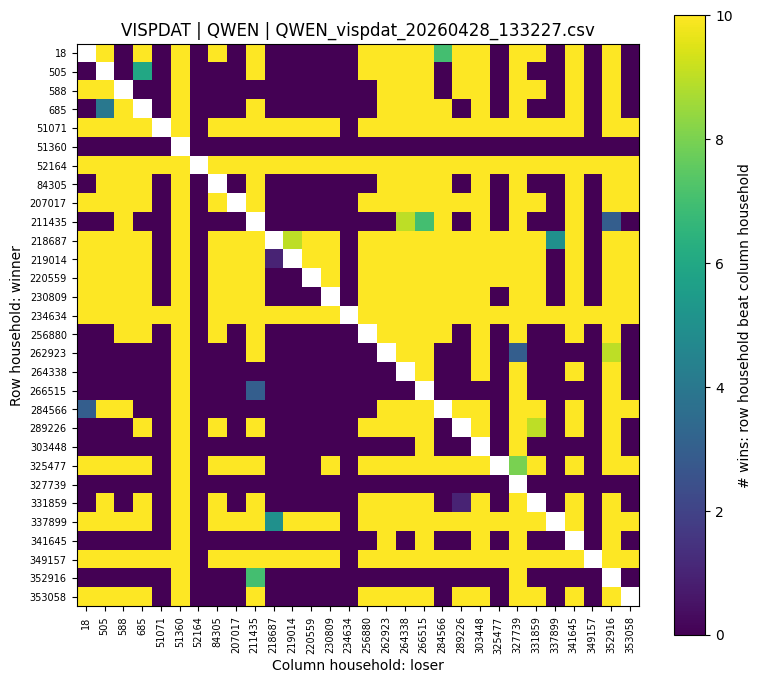

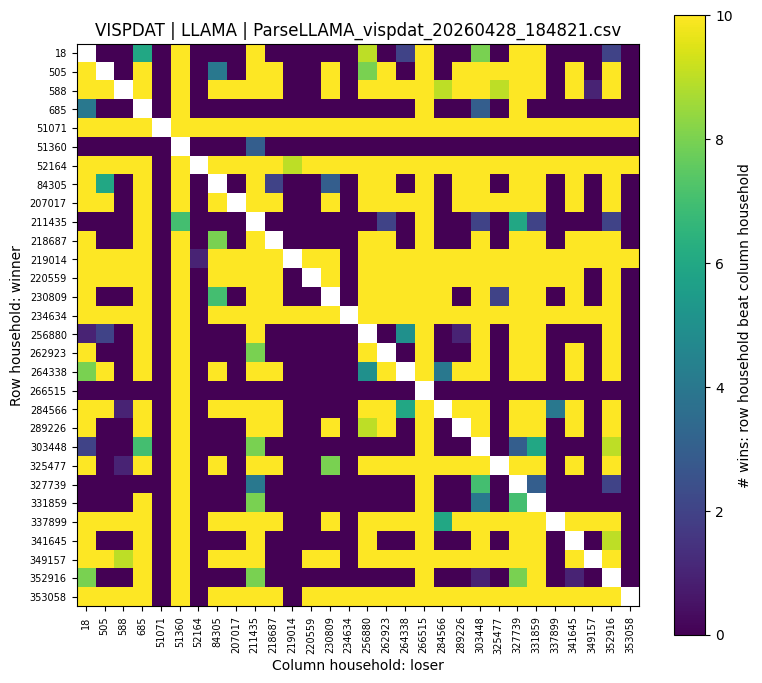

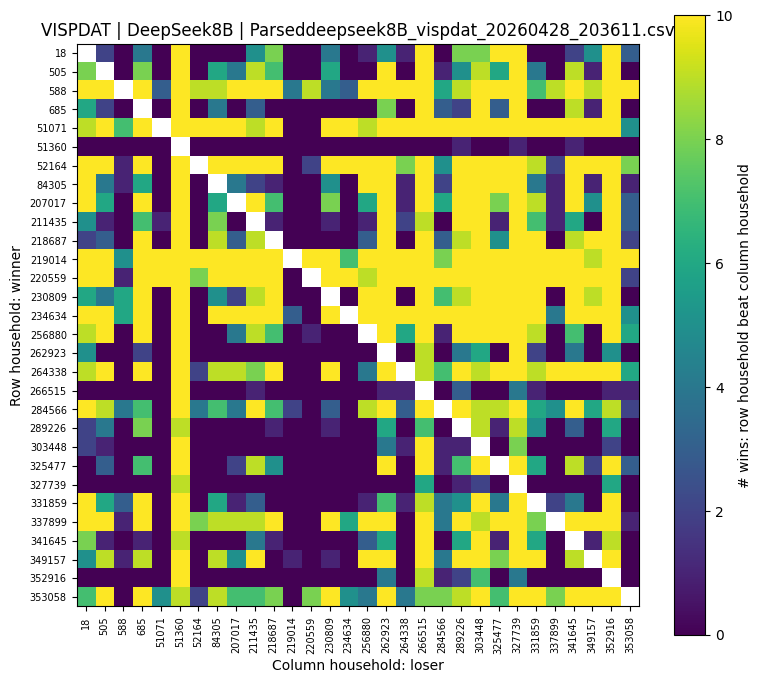

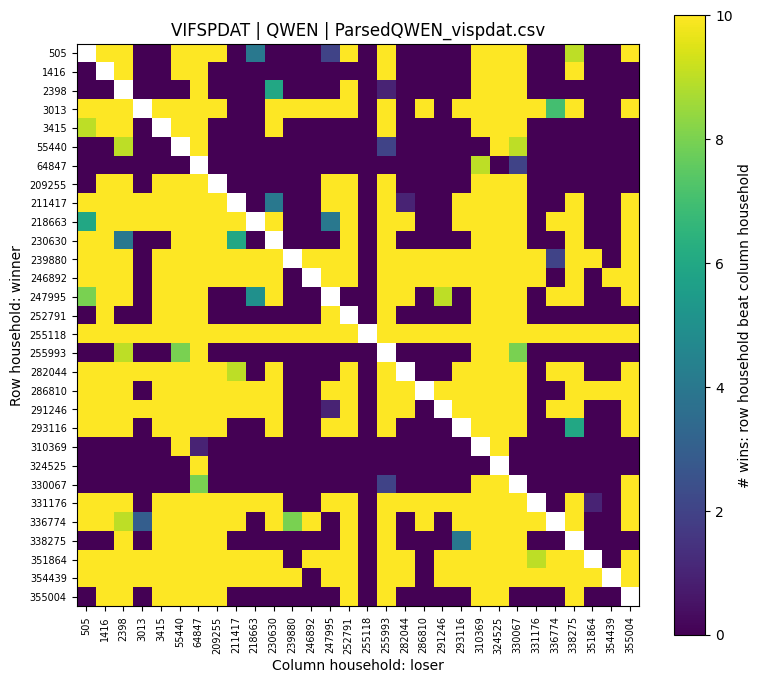

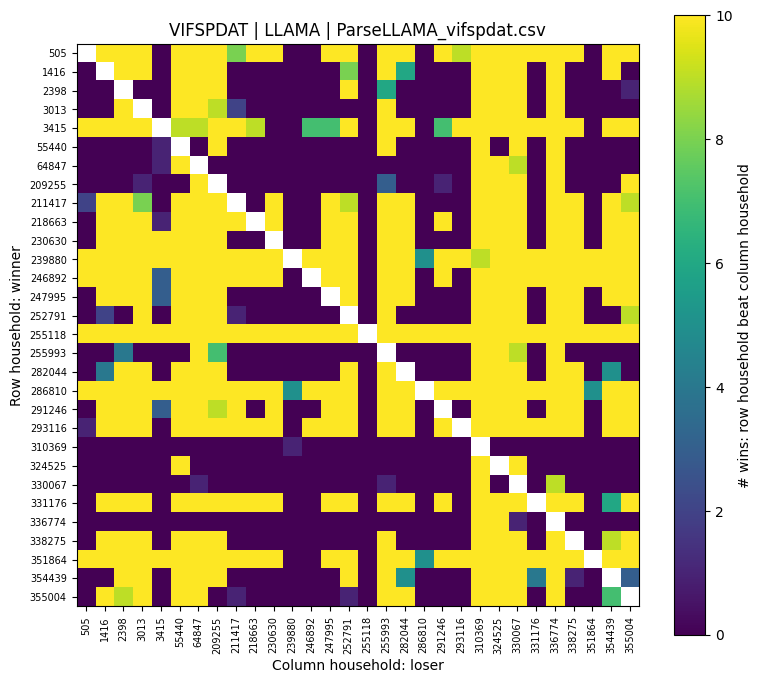

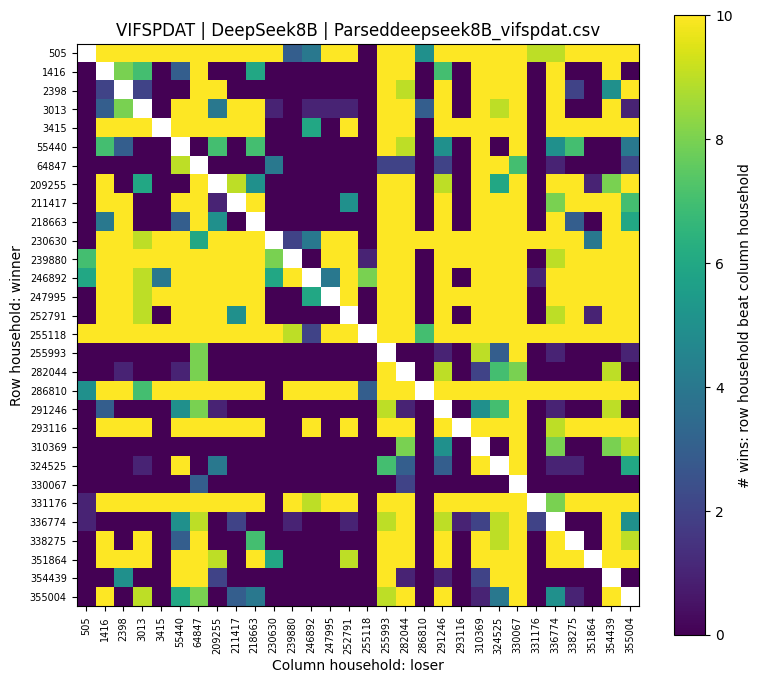

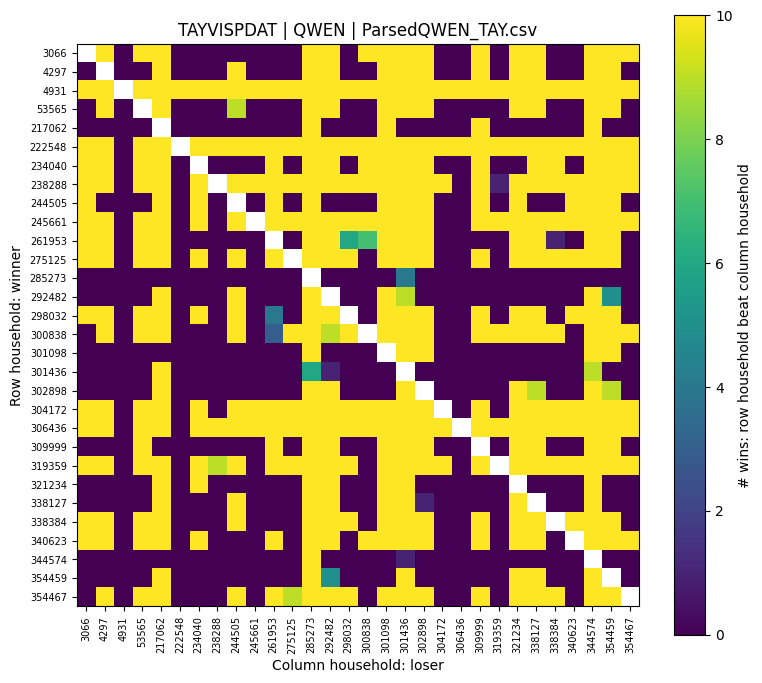

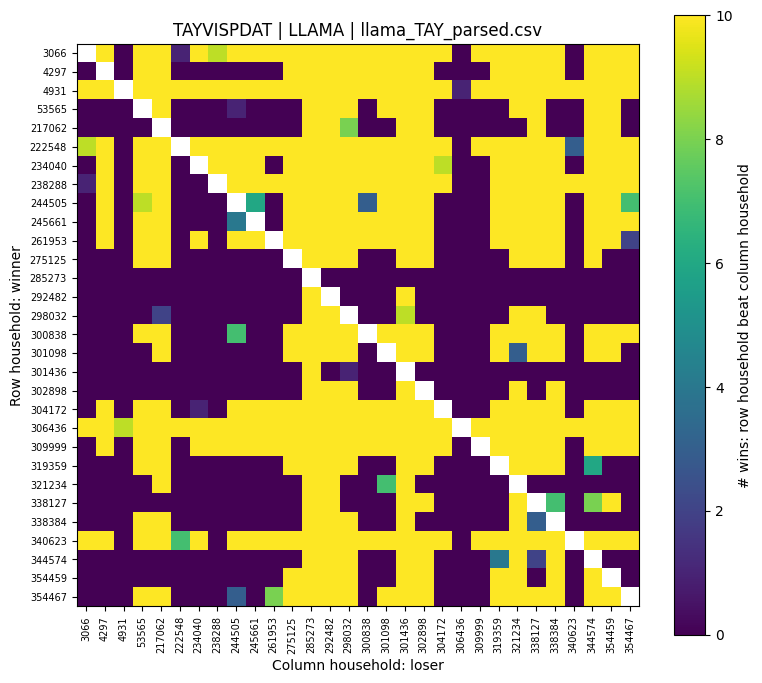

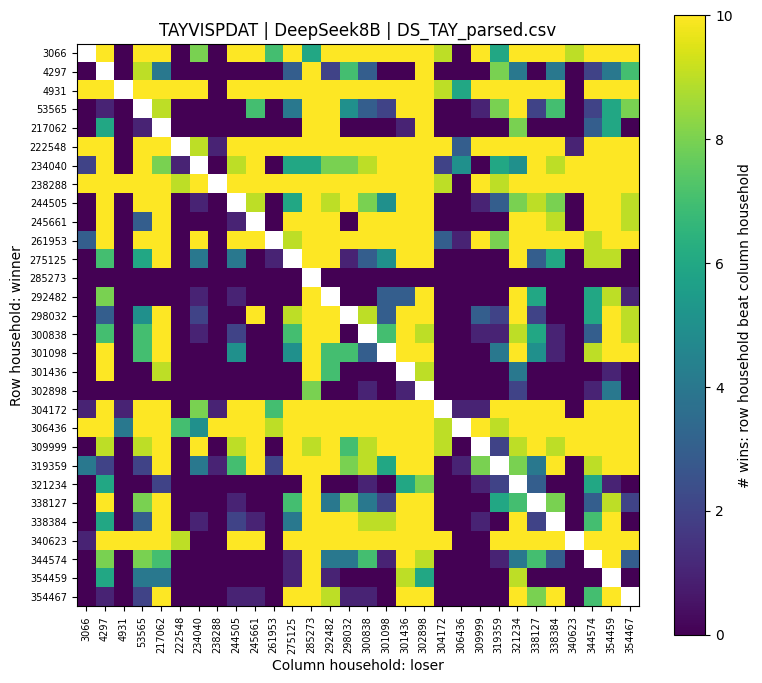

In [11]:
output_dir = "win_matrix_plots"

for config in file_configs:
    dataset = config["dataset"]
    model = config["model"]
    file_name = config["file"]

    result, df_selected, win_matrix, win_df = build_win_count_matrix_for_file(
        dataset=dataset,
        model=model,
        file_name=file_name,
    )

    title = f"{dataset} | {model} | {file_name}"

    save_path = os.path.join(
        output_dir,
        f"{dataset}_{model}_{file_name}_win_matrix.png"
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )

    plot_win_matrix(
        win_matrix=win_matrix,
        house_ids=result["house_ids"],
        title=title,
        annotate=False,
        figsize=(8, 7),
        save_path=save_path,
        show=True,
    )

In [13]:
import os
import json
import numpy as np


def safe_name(x):
    return (
        str(x)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace(":", "_")
    )


output_dir = "raw_win_matrices"
os.makedirs(output_dir, exist_ok=True)

for config in file_configs:
    dataset = config["dataset"]
    model = config["model"]
    file_name = config["file"]

    result, valid_df, win_matrix, win_df = build_win_count_matrix_for_file(
        dataset=dataset,
        model=model,
        file_name=file_name,
    )

    base_name = f"{safe_name(dataset)}__{safe_name(model)}__{safe_name(file_name)}"

    npy_path = os.path.join(output_dir, base_name + "__win_matrix.npy")
    csv_path = os.path.join(output_dir, base_name + "__win_matrix_labeled.csv")
    meta_path = os.path.join(output_dir, base_name + "__metadata.json")

    # 1. Save raw NumPy matrix
    np.save(npy_path, win_matrix)

    # 2. Save labeled DataFrame version
    win_df.to_csv(csv_path)

    # 3. Save metadata, especially household ordering
    metadata = {
        "dataset": dataset,
        "model": model,
        "file": file_name,
        "version": result["version"],
        "num_house": result["num_house"],
        "house_ids": result["house_ids"],
        "house_to_idx": result["house_to_idx"],
        "idx_to_house": result["idx_to_house"],
        "num_valid_rows": result["num_valid_rows"],
        "num_total_wins_recorded": result["num_total_wins_recorded"],
        "max_cell_value": result["max_cell_value"],
        "npy_path": npy_path,
        "csv_path": csv_path,
    }

    with open(meta_path, "w") as f:
        json.dump(metadata, f, indent=2)

    print("Saved:")
    print(" ", npy_path)
    print(" ", csv_path)
    print(" ", meta_path)
    print()

Saved:
  raw_win_matrices\VISPDAT__QWEN__QWEN_vispdat_20260428_133227.csv__win_matrix.npy
  raw_win_matrices\VISPDAT__QWEN__QWEN_vispdat_20260428_133227.csv__win_matrix_labeled.csv
  raw_win_matrices\VISPDAT__QWEN__QWEN_vispdat_20260428_133227.csv__metadata.json

Saved:
  raw_win_matrices\VISPDAT__LLAMA__ParseLLAMA_vispdat_20260428_184821.csv__win_matrix.npy
  raw_win_matrices\VISPDAT__LLAMA__ParseLLAMA_vispdat_20260428_184821.csv__win_matrix_labeled.csv
  raw_win_matrices\VISPDAT__LLAMA__ParseLLAMA_vispdat_20260428_184821.csv__metadata.json

Saved:
  raw_win_matrices\VISPDAT__DeepSeek8B__Parseddeepseek8B_vispdat_20260428_203611.csv__win_matrix.npy
  raw_win_matrices\VISPDAT__DeepSeek8B__Parseddeepseek8B_vispdat_20260428_203611.csv__win_matrix_labeled.csv
  raw_win_matrices\VISPDAT__DeepSeek8B__Parseddeepseek8B_vispdat_20260428_203611.csv__metadata.json

Saved:
  raw_win_matrices\VIFSPDAT__QWEN__ParsedQWEN_vispdat.csv__win_matrix.npy
  raw_win_matrices\VIFSPDAT__QWEN__ParsedQWEN_vispda